# Solar Panel Segmentation Pipeline

End-to-end pipeline: load test images, run a trained YOLO model, track experiments with MLflow, evaluate on labeled data, and visualize results.

## Pipeline Architecture


```

| Stage | Notebook section | Purpose |
|-------|------------------|---------|
| 1 | Data Input | Discover inference and evaluation images |
| 2 | Load Model | Load trained YOLO weights |
| 3 | MLflow | Track parameters, metrics, and artifacts |
| 4 | Inference Layer | Predict masks for all images |
| 5 | Save Results | Precision, recall, F1, area table, CSV/JSON |
| 6 | Present Results | Overlays, plots, and summary |

## How to run

1. Set the working directory to `gd a revelia` (where `dados_teste/` and `best.pt` live).
2. Run all cells top to bottom (**Cell → Run All**).
3. See `README_segmentation_pipeline.md` for dependencies and output paths.


## Setup

Install dependencies if needed (uncomment the line below).


In [12]:
# %pip install ultralytics opencv-python mlflow scikit-learn matplotlib pandas tqdm torch

import json
import os
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

CONFIG = {
    "MODEL_PATH": "best.pt",
    "MODEL_FALLBACK": "runs/train/solar_panels_v1/weights/best.pt",
    "MODEL_SEG_FALLBACK": "yolov8n-seg.pt",
    "INFERENCE_DIR": "dados_teste",
    "DATASET_DIR": "dataset_yolo",
    "OUTPUT_DIR": "results/segmentation_pipeline",
    "MLFLOW_TRACKING_URI": "./mlruns",
    "MLFLOW_EXPERIMENT": "solar-panel-segmentation",
    "CONF_THRESHOLD": 0.25,
    "IOU_THRESHOLD": 0.45,
    "MASK_THRESHOLD": 0.5,
    "RUN_NAME": "segmentation_inference_eval",
    "METERS_PER_PIXEL": 0.3,
    "POWER_KW_PER_SQM": 0.15,
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)
print("Setup complete. Output dir:", CONFIG["OUTPUT_DIR"])


Setup complete. Output dir: results/segmentation_pipeline


---
## Stage 1 — Data Input

Two image sources:

- **Inference set:** all PNGs in `dados_teste/` (batch scoring).
- **Evaluation set:** images in `dataset_yolo` that have a matching YOLO label file (used for precision, recall, and F1).


In [13]:
def resolve_model_path():
    candidates = [
        Path(CONFIG["MODEL_PATH"]),
        Path(CONFIG["MODEL_FALLBACK"]),
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    return CONFIG["MODEL_PATH"]


def list_inference_images(directory):
    root = Path(directory)
    if not root.exists():
        raise FileNotFoundError(f"Inference directory not found: {root}")
    return sorted(root.glob("*.png"))


def list_labeled_eval_images(dataset_dir):
    root = Path(dataset_dir)
    eval_items = []
    for split in ("train", "val", "test"):
        img_dir = root / "images" / split
        label_dir = root / "labels" / split
        if not label_dir.exists():
            continue
        for label_path in sorted(label_dir.glob("*.txt")):
            stem = label_path.stem
            for ext in (".png", ".jpg", ".jpeg"):
                img_path = img_dir / f"{stem}{ext}"
                if img_path.exists():
                    eval_items.append({
                        "path": img_path,
                        "split": split,
                        "label_path": label_path,
                        "stem": stem,
                    })
                    break
    return eval_items


inference_images = list_inference_images(CONFIG["INFERENCE_DIR"])
eval_items = list_labeled_eval_images(CONFIG["DATASET_DIR"])
model_path_resolved = resolve_model_path()

print(f"Inference images: {len(inference_images)}")
print(f"Labeled eval images: {len(eval_items)}")
print(f"Model path (resolved): {model_path_resolved}")
print(f"Model exists: {Path(model_path_resolved).exists()}")
if inference_images:
    print("Sample inference:", inference_images[0].name)
if eval_items:
    print("Sample eval:", eval_items[0]["path"].name, f"({eval_items[0]['split']})")


Inference images: 52
Labeled eval images: 15
Model path (resolved): best.pt
Model exists: True
Sample inference: 1004739 (1).png
Sample eval: 1036553.png (train)


---
## Stage 2 — Load Trained Model

Load the fine-tuned YOLO weights and detect whether the model returns native segmentation masks or detection boxes only.


In [14]:
def load_yolo_model(path):
    p = Path(path)
    if not p.exists():
        print(f"Warning: {path} not found. Trying segmentation fallback: {CONFIG['MODEL_SEG_FALLBACK']}")
        return YOLO(CONFIG["MODEL_SEG_FALLBACK"]), CONFIG["MODEL_SEG_FALLBACK"]
    return YOLO(str(p)), str(p)


model, loaded_model_path = load_yolo_model(model_path_resolved)
print(f"Model loaded: {loaded_model_path}")
print(f"Classes: {model.names}")

probe_path = str(eval_items[0]["path"] if eval_items else inference_images[0])
test_result = model.predict(source=probe_path, conf=CONFIG["CONF_THRESHOLD"], verbose=False, task="segment")
has_native_segmentation = test_result[0].masks is not None

if has_native_segmentation:
    print("Native segmentation: supported.")
else:
    print("Detection-only model: masks will be approximated from bounding boxes.")


Model loaded: best.pt
Classes: {0: 'solar-panel'}
Native segmentation: supported.


---
## Stage 3 — MLflow Tracking

Start an MLflow run and log configuration before inference. Metrics and artifacts are logged after Stage 5.


In [17]:
mlflow.set_tracking_uri(CONFIG["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(CONFIG["MLFLOW_EXPERIMENT"])

# Safe re-run: end any leftover active run from a previous partial execution
if mlflow.active_run() is not None:
    print(f"Ending previous active run: {mlflow.active_run().info.run_id}")
    mlflow.end_run()

mlflow_run = mlflow.start_run(run_name=CONFIG["RUN_NAME"])

mlflow.log_params({
    "model_path": loaded_model_path,
    "has_native_segmentation": has_native_segmentation,
    "conf_threshold": CONFIG["CONF_THRESHOLD"],
    "iou_threshold": CONFIG["IOU_THRESHOLD"],
    "mask_threshold": CONFIG["MASK_THRESHOLD"],
    "n_inference_images": len(inference_images),
    "n_eval_images": len(eval_items),
    "inference_dir": CONFIG["INFERENCE_DIR"],
    "dataset_dir": CONFIG["DATASET_DIR"],
})

print(f"MLflow run started: {mlflow_run.info.run_id}")
print(f"Tracking URI: {CONFIG['MLFLOW_TRACKING_URI']}")


Ending previous active run: 4b70cd44080c45138fa1d35f895f7f36
MLflow run started: 5c9590e72ecf49eba8e6e7667463a645
Tracking URI: ./mlruns


---
## Stage 4 — Inference Layer

Modular functions for prediction and mask extraction. The same layer runs on the full inference set and on the labeled evaluation subset.


In [19]:
class FakeMasks:
    def __init__(self, data):
        self.data = data


def predict_image(model, image_path, native_seg):
    task = "segment" if native_seg else "detect"
    results = model.predict(
        source=str(image_path),
        conf=CONFIG["CONF_THRESHOLD"],
        iou=CONFIG["IOU_THRESHOLD"],
        verbose=False,
        task=task,
    )
    return results[0]


def extract_masks(result, image_path):
    masks = result.masks
    if masks is not None and masks.data is not None and len(masks.data) > 0:
        return masks

    if result.boxes is None or len(result.boxes) == 0:
        return None

    img = cv2.imread(str(image_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    mask_list = []
    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = box.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        mask = np.zeros((h, w), dtype=np.float32)
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = 1.0
        mask_list.append(torch.from_numpy(mask))

    if not mask_list:
        return None
    return FakeMasks(torch.stack(mask_list))


def mask_to_numpy(mask, h, w):
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy()
    else:
        mask_np = np.asarray(mask)
    if mask_np.shape != (h, w):
        mask_np = cv2.resize(mask_np.astype(np.float32), (w, h))
    return mask_np


def combined_binary_mask(masks, h, w, threshold=None):
    threshold = threshold or CONFIG["MASK_THRESHOLD"]
    combined = np.zeros((h, w), dtype=np.uint8)
    if masks is None or masks.data is None:
        return combined
    for mask in masks.data:
        mask_np = mask_to_numpy(mask, h, w)
        combined = np.maximum(combined, (mask_np > threshold).astype(np.uint8))
    return combined


def process_single_image(model, image_path, native_seg):
    result = predict_image(model, image_path, native_seg)
    masks = extract_masks(result, image_path)
    img = cv2.imread(str(image_path))
    h, w = img.shape[:2]
    num_segments = len(masks.data) if masks is not None and masks.data is not None else 0

    total_area_pixels = 0
    if masks is not None and masks.data is not None and num_segments > 0:
        for mask in masks.data:
            mask_np = mask_to_numpy(mask, h, w)
            total_area_pixels += int(np.sum(mask_np > CONFIG["MASK_THRESHOLD"]))

    if num_segments > 0 and result.boxes is not None and len(result.boxes) > 0:
        confidences = result.boxes.conf.cpu().numpy()
        avg_conf = float(np.mean(confidences))
        max_conf = float(np.max(confidences))
        min_conf = float(np.min(confidences))
    else:
        avg_conf = max_conf = min_conf = 0.0

    total_pixels = h * w
    coverage = (total_area_pixels / total_pixels * 100) if total_pixels > 0 else 0.0

    return {
        "image": image_path.name,
        "path": str(image_path),
        "num_segments": num_segments,
        "area_pixels": total_area_pixels,
        "coverage_pct": coverage,
        "conf_mean": avg_conf,
        "conf_max": max_conf,
        "conf_min": min_conf,
        "result": result,
        "masks": masks,
        "pred_mask": combined_binary_mask(masks, h, w),
        "height": h,
        "width": w,
    }


def run_inference_on_images(model, image_paths, native_seg, desc="Inference"):
    results = []
    for img_path in tqdm(image_paths, desc=desc):
        results.append(process_single_image(model, img_path, native_seg))
    return results


inference_results = run_inference_on_images(
    model, inference_images, has_native_segmentation, desc="Inference (dados_teste)"
)
eval_paths = [item["path"] for item in eval_items]
eval_inference_results = run_inference_on_images(
    model, eval_paths, has_native_segmentation, desc="Inference (labeled eval)"
)

print(f"Done: {len(inference_results)} inference + {len(eval_inference_results)} eval images.")


Inference (labeled eval): 100%|██████████| 15/15 [00:03<00:00,  4.21it/s]

Done: 52 inference + 15 eval images.


---
## Stage 5 — Save Results

**Metrics** (labeled subset only): pixel-level binary segmentation — solar panel vs background. Ground truth masks are rasterized from YOLO bounding-box labels.

**Exports:** CSV/JSON/PNG under `results/segmentation_pipeline/` and MLflow artifacts.


In [20]:
def yolo_boxes_to_mask(label_path, width, height):
    mask = np.zeros((height, width), dtype=np.uint8)
    lines = Path(label_path).read_text(encoding="utf-8").strip().splitlines()
    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue
        _, cx, cy, bw, bh = map(float, parts[:5])
        x1 = int((cx - bw / 2) * width)
        y1 = int((cy - bh / 2) * height)
        x2 = int((cx + bw / 2) * width)
        y2 = int((cy + bh / 2) * height)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(width, x2), min(height, y2)
        if x2 > x1 and y2 > y1:
            mask[y1:y2, x1:x2] = 1
    return mask


def mask_iou(gt, pred):
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return float(inter / union) if union > 0 else 0.0


per_image_rows = []
y_true_all, y_pred_all = [], []

for item, pred_row in zip(eval_items, eval_inference_results):
    h, w = pred_row["height"], pred_row["width"]
    gt_mask = yolo_boxes_to_mask(item["label_path"], w, h)
    pred_mask = pred_row["pred_mask"]
    gt_flat = gt_mask.ravel()
    pred_flat = pred_mask.ravel()
    y_true_all.append(gt_flat)
    y_pred_all.append(pred_flat)
    tp = int(np.logical_and(gt_mask == 1, pred_mask == 1).sum())
    fp = int(np.logical_and(gt_mask == 0, pred_mask == 1).sum())
    fn = int(np.logical_and(gt_mask == 1, pred_mask == 0).sum())
    per_image_rows.append({
        "image": item["stem"],
        "split": item["split"],
        "iou": mask_iou(gt_mask, pred_mask),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "num_segments_pred": pred_row["num_segments"],
    })

y_true = np.concatenate(y_true_all) if y_true_all else np.array([])
y_pred = np.concatenate(y_pred_all) if y_pred_all else np.array([])

if len(y_true) > 0:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall = float(recall_score(y_true, y_pred, zero_division=0))
    f1 = float(f1_score(y_true, y_pred, zero_division=0))
    pixel_accuracy = float((y_true == y_pred).mean())
    mean_iou = float(np.mean([r["iou"] for r in per_image_rows]))
else:
    cm = np.zeros((2, 2))
    precision = recall = f1 = pixel_accuracy = mean_iou = 0.0

metrics_summary = {
    "n_eval_images": len(eval_items),
    "n_inference_images": len(inference_images),
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "pixel_accuracy": pixel_accuracy,
    "mean_iou": mean_iou,
    "confusion_matrix": cm.tolist(),
    "labels": ["background", "solar_panel"],
}

out = Path(CONFIG["OUTPUT_DIR"])
df_inference = pd.DataFrame([
    {
        "image": r["image"],
        "num_segments": r["num_segments"],
        "area_pixels": r["area_pixels"],
        "coverage_pct": r["coverage_pct"],
        "conf_mean": r["conf_mean"],
        "conf_max": r["conf_max"],
        "conf_min": r["conf_min"],
    }
    for r in inference_results
])
df_inference.to_csv(out / "inference_results.csv", index=False, encoding="utf-8-sig")

df_per_image = pd.DataFrame(per_image_rows)
df_per_image.to_csv(out / "metrics_per_image.csv", index=False, encoding="utf-8-sig")

with open(out / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

mlflow.log_metrics({
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "pixel_accuracy": pixel_accuracy,
    "mean_iou": mean_iou,
})
mlflow.log_artifact(str(out / "metrics_summary.json"))
mlflow.log_artifact(str(out / "metrics_per_image.csv"))
mlflow.log_artifact(str(out / "inference_results.csv"))

print("Saved to:", out)
print(json.dumps({
    k: metrics_summary[k]
    for k in ("precision", "recall", "f1", "pixel_accuracy", "mean_iou")
}, indent=2))


Saved to: results\segmentation_pipeline
{
  "precision": 0.9720293315767323,
  "recall": 0.2769502168790274,
  "f1": 0.43107788998754376,
  "pixel_accuracy": 0.9543560384114583,
  "mean_iou": 0.25369668742510526
}


---
## Stage 6 — Present Inference and Results

Visualize predictions on sample images, display evaluation metrics, and show a **detected area table** with two didactic examples at the end.


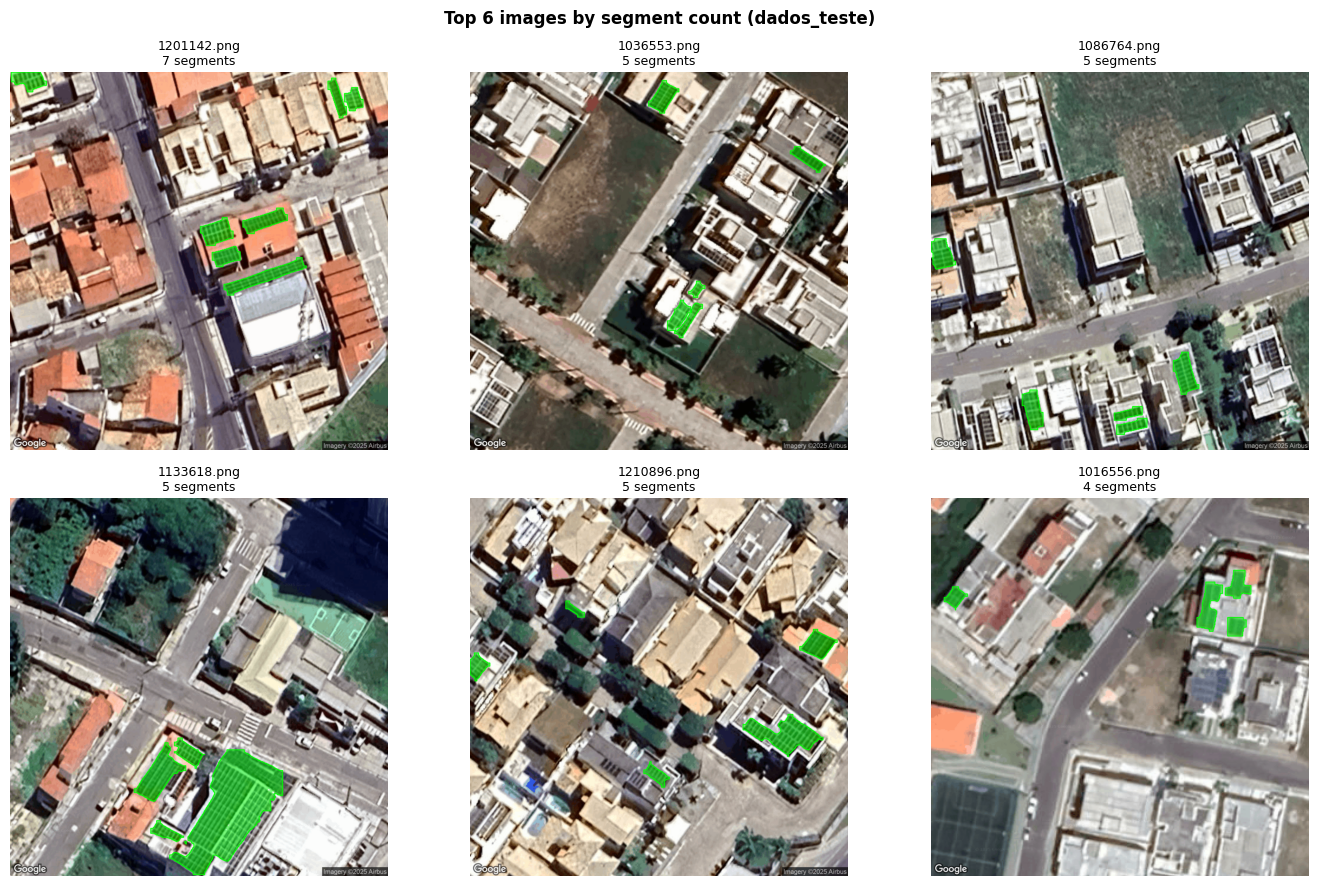


=== Evaluation metrics (labeled subset) ===
            Metric  Value
         precision 0.9720
            recall 0.2770
                f1 0.4311
    pixel_accuracy 0.9544
          mean_iou 0.2537
     n_eval_images     15
n_inference_images     52


In [21]:
def visualize_segmentation(img_path, masks, ax, title=None):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    overlay = img_rgb.copy()

    if masks is not None and masks.data is not None and len(masks.data) > 0:
        combined = np.zeros((h, w), dtype=np.uint8)
        for mask in masks.data:
            mask_np = mask_to_numpy(mask, h, w)
            combined = np.maximum(combined, (mask_np > CONFIG["MASK_THRESHOLD"]).astype(np.uint8))
        overlay[combined > 0] = [0, 255, 0]
        img_rgb = cv2.addWeighted(img_rgb, 0.5, overlay, 0.5, 0)
        contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(img_rgb, contours, -1, (0, 255, 0), 2)

    ax.imshow(img_rgb)
    ax.axis("off")
    n = len(masks.data) if masks is not None and masks.data is not None else 0
    ax.set_title(title or f"{Path(img_path).name}\n{n} segments", fontsize=9)


df_inf = pd.DataFrame([{"image": r["image"], "num_segments": r["num_segments"]} for r in inference_results])
top6 = df_inf.nlargest(6, "num_segments")["image"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, name in zip(axes.flatten(), top6):
    row = next(r for r in inference_results if r["image"] == name)
    visualize_segmentation(row["path"], row["masks"], ax)
plt.suptitle("Top 6 images by segment count (dados_teste)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

summary_display = pd.DataFrame([{
    "Metric": k,
    "Value": f"{metrics_summary[k]:.4f}" if isinstance(metrics_summary[k], float) else metrics_summary[k],
} for k in ("precision", "recall", "f1", "pixel_accuracy", "mean_iou", "n_eval_images", "n_inference_images")])
print("\n=== Evaluation metrics (labeled subset) ===")
print(summary_display.to_string(index=False))


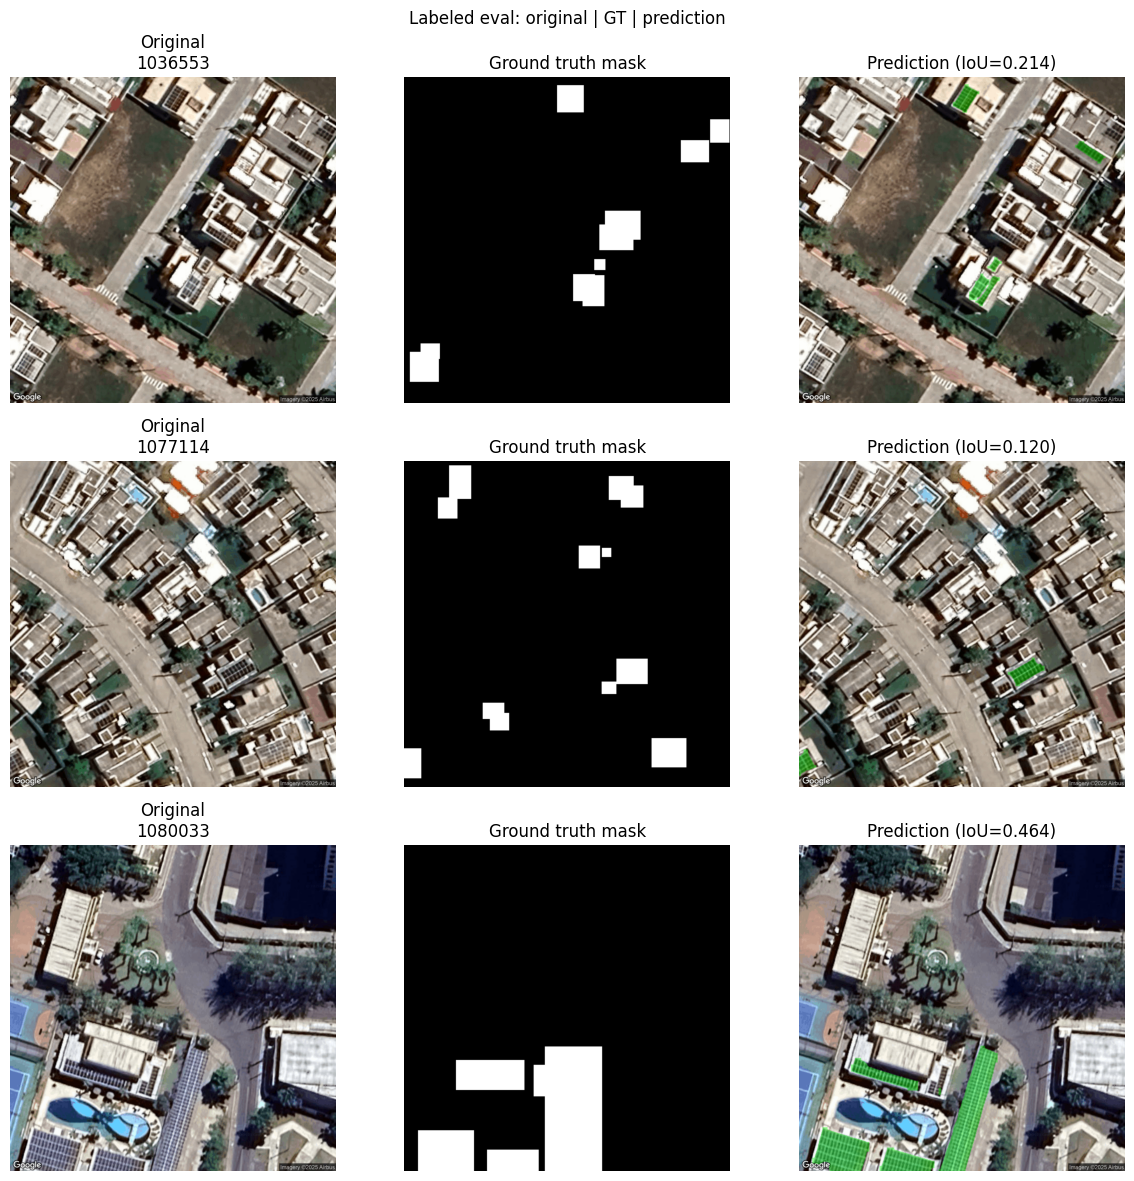


=== Detected area per image (all inference set) ===
Assumptions: 0.3 m/pixel, 0.15 kW/m²
          image  num_segments  area_pixels  area_m2  coverage_pct  est_power_kw
    1132186.png             1       112256 10103.04      6.851562      1515.456
    1133618.png             5       102636  9237.24      6.264404      1385.586
    1080033.png             4        94544  8508.96      5.770508      1276.344
    1201142.png             7        41540  3738.60      2.535400       560.790
    1102679.png             2        40416  3637.44      2.466797       545.616
    1234633.png             4        38656  3479.04      2.359375       521.856
    1210896.png             5        32500  2925.00      1.983643       438.750
    1139712.png             4        31036  2793.24      1.894287       418.986
    1153492.png             4        28184  2536.56      1.720215       380.484
    1086764.png             5        26360  2372.40      1.608887       355.860
    1152604.png             2 

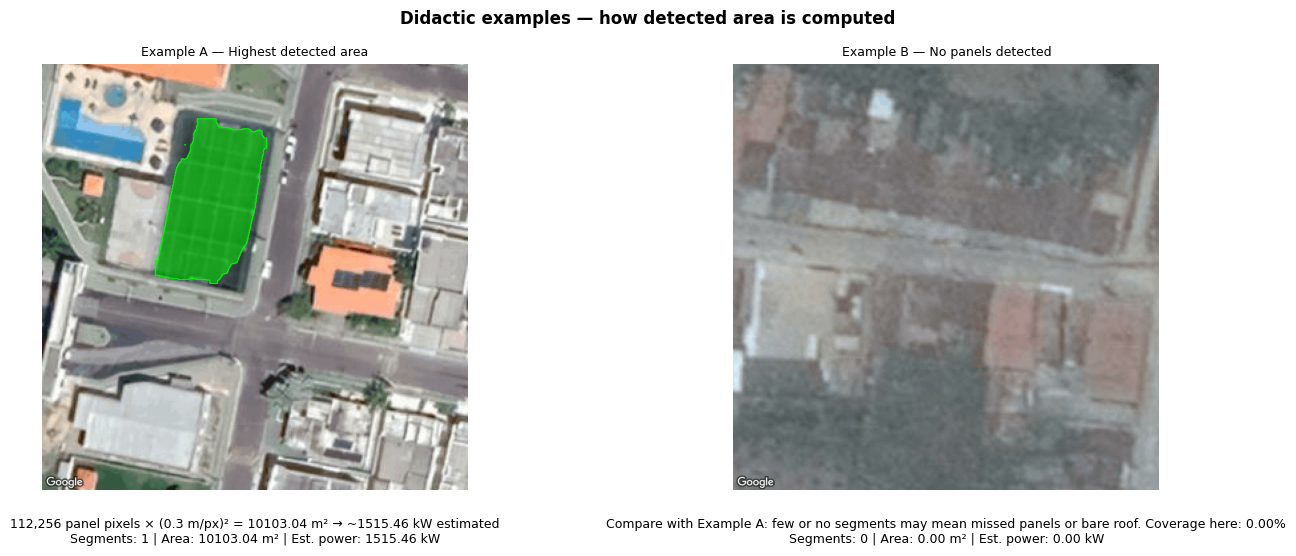

PIPELINE SUMMARY
Model: best.pt
Native segmentation: True
Inference images: 52
Images with detections: 31 (59.6%)
Eval images (labeled): 15
Precision: 0.9720 | Recall: 0.2770 | F1: 0.4311
Results: results\segmentation_pipeline
MLflow run: 5c9590e72ecf49eba8e6e7667463a645
MLflow run ended.


In [22]:
n_show = min(3, len(eval_items))
if n_show > 0:
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, 0)
    for i, (item, pred_row) in enumerate(zip(eval_items[:n_show], eval_inference_results[:n_show])):
        img = cv2.cvtColor(cv2.imread(str(item["path"])), cv2.COLOR_BGR2RGB)
        gt = yolo_boxes_to_mask(item["label_path"], pred_row["width"], pred_row["height"])
        pr = pred_row["pred_mask"]
        overlay = img.copy()
        overlay[pr > 0] = [0, 255, 0]
        blend = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Original\n{item['stem']}")
        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground truth mask")
        axes[i, 2].imshow(blend)
        axes[i, 2].set_title(f"Prediction (IoU={per_image_rows[i]['iou']:.3f})")
        for j in range(3):
            axes[i, j].axis("off")
    plt.suptitle("Labeled eval: original | GT | prediction", fontsize=12)
    plt.tight_layout()
    plt.show()

# --- Detected area table + didactic examples ---
mpp = CONFIG["METERS_PER_PIXEL"]
power_per_sqm = CONFIG["POWER_KW_PER_SQM"]

df_area = pd.DataFrame([
    {
        "image": r["image"],
        "num_segments": r["num_segments"],
        "area_pixels": r["area_pixels"],
        "area_m2": r["area_pixels"] * (mpp ** 2),
        "coverage_pct": r["coverage_pct"],
        "est_power_kw": r["area_pixels"] * (mpp ** 2) * power_per_sqm,
    }
    for r in inference_results
]).sort_values("area_m2", ascending=False)

df_area.to_csv(out / "detected_area_table.csv", index=False, encoding="utf-8-sig")
mlflow.log_artifact(str(out / "detected_area_table.csv"))

print("\n=== Detected area per image (all inference set) ===")
print(f"Assumptions: {mpp} m/pixel, {power_per_sqm} kW/m²")
display_cols = ["image", "num_segments", "area_pixels", "area_m2", "coverage_pct", "est_power_kw"]
print(df_area[display_cols].to_string(index=False))

def _result_by_image(name):
    return next(r for r in inference_results if r["image"] == name)

row_high = df_area.iloc[0]
ex_high = _result_by_image(row_high["image"])

zero_panel = df_area[df_area["num_segments"] == 0]
if len(zero_panel) > 0:
    row_low = zero_panel.iloc[0]
    ex_low_label = "Example B — No panels detected"
else:
    row_low = df_area.iloc[-1]
    ex_low_label = "Example B — Lowest detected area"
ex_low = _result_by_image(row_low["image"])

didactic_examples = [
    {
        "label": "Example A — Highest detected area",
        "row": ex_high,
        "stats": row_high,
        "note": (
            f"{int(row_high['area_pixels']):,} panel pixels × ({mpp} m/px)² "
            f"= {row_high['area_m2']:.2f} m² → ~{row_high['est_power_kw']:.2f} kW estimated"
        ),
    },
    {
        "label": ex_low_label,
        "row": ex_low,
        "stats": row_low,
        "note": (
            "Compare with Example A: few or no segments may mean missed panels or bare roof. "
            f"Coverage here: {row_low['coverage_pct']:.2f}%"
        ),
    },
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ex in zip(axes, didactic_examples):
    visualize_segmentation(ex["row"]["path"], ex["row"]["masks"], ax, title=ex["label"])
    s = ex["stats"]
    ax.text(
        0.5, -0.12,
        f"{ex['note']}\nSegments: {int(s['num_segments'])} | Area: {s['area_m2']:.2f} m² | Est. power: {s['est_power_kw']:.2f} kW",
        transform=ax.transAxes, ha="center", fontsize=9, wrap=True,
    )
plt.suptitle("Didactic examples — how detected area is computed", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

images_with_panels = sum(1 for r in inference_results if r["num_segments"] > 0)
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"Model: {loaded_model_path}")
print(f"Native segmentation: {has_native_segmentation}")
print(f"Inference images: {len(inference_results)}")
print(f"Images with detections: {images_with_panels} ({100 * images_with_panels / max(len(inference_results), 1):.1f}%)")
print(f"Eval images (labeled): {len(eval_items)}")
print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
print(f"Results: {out}")
print(f"MLflow run: {mlflow_run.info.run_id}")
print("=" * 60)

if mlflow.active_run() is not None:
    mlflow.end_run()
    print("MLflow run ended.")
else:
    print("No active MLflow run to end.")
